# Ramadan Cognitive Readiness Study — Data Exploration Notebook
## eyeTech Platform · UM6P Human-AI Interaction Laboratory

---

**Study:** Webcam-based gaze assessment of cognitive readiness across Ramadan fasting states  
**Data:** 62 sessions · 19 participants · March 2026  
**Analyst:** Safae Meftah Menani & Mohammed Tahri Sqalli

---

### What this notebook covers

| Section | Focus |
|---|---|
| 1 | Setup & data loading |
| 2 | Data quality audit — reliability classification |
| 3 | Descriptive statistics |
| 4 | Normality tests |
| 5 | Time-of-day patterns (B1) |
| 6 | Reliability comparison (B2) |
| 7 | Suhoor timing effect (A3/A6) |
| 8 | Sleep stratification (B4) |
| 9 | Gender analysis (E1) |
| 10 | Device type (B3) |
| 11 | Calibration as analytical variable (F3) |
| 12 | Sub-score divergence — metabolic conservation (A5) |
| 13 | Raw feature correlations |
| 14 | Summary of findings |

> **Two-layer robustness rule:** Every analysis is run first on **all 62 sessions**, then replicated on the **34 high-reliability sessions only**. Results that hold in both layers are robust.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, wilcoxon, spearmanr, shapiro
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded.")


Libraries loaded.


In [2]:
# ── Load data ──
CSV_PATH = "ramadan_data.csv"   # adjust path if needed
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# Parse timestamps
df['recordedAt'] = pd.to_datetime(df['recordedAt'], format='mixed', utc=True)
df['hour'] = df['recordedAt'].dt.hour
df['date'] = df['recordedAt'].dt.date

# Time window
df['time_window'] = pd.cut(
    df['hour'], bins=[0, 6, 12, 18, 24],
    labels=['Night (0-6h)', 'Morning (6-12h)', 'Afternoon (12-18h)', 'Evening (18-24h)']
)

# Ordered categorical variables
suhoor_order = ['I did not have Suhoor today',
                'Less than 30 minutes before Fajr',
                '30-60 minutes before Fajr',
                'More than 60 minutes before Fajr']
sleep_order  = ['Less than 4 hours', '4-5 hours', '6-7 hours', '8-9 hours', 'More than 9 hours']

df['suhoorTiming'] = pd.Categorical(df['suhoorTiming'], categories=suhoor_order, ordered=True)
df['sleepHours']   = pd.Categorical(df['sleepHours'],   categories=sleep_order,  ordered=True)

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Unique participants: {df['student.id'].nunique()}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head(3)


Loaded: 62 rows x 56 columns
Unique participants: 19
Date range: 2026-02-26 → 2026-04-01


,id,student.id,student.fullName,student.firstName,student.lastName,student.email,student.ageRange,student.questionnaireGender,student.occupationStatus,student.jobTitle,...,postStudyEaseOfUse,postStudyReportValue,postStudySubmittedAt,aiAnalysisProvider,aiAnalysisGeneratedAt,full_name_display,screen_profile,hour,date,time_window
0,106,45,Mouline,NaN,NaN,r.mouline@ocpgroup.ma,45-54 years,Male,Business/Management,NaN,...,4.0,4.0,2026-04-01T11:15:45.457Z,Groq,2026-04-01T11:14:57.351Z,Mouline,Approx. 13-17 in laptop • 1440x900 • 1440x812 ...,11,2026-04-01,Morning (6-12h)
1,105,32,Sarah,NaN,NaN,sarah.benmerzouk@um6p.ma,25-34 years,Female,Business/Management,NaN,...,NaN,NaN,NaN,Groq,2026-04-04T13:04:56.106Z,Sarah,External monitor / desktop display • 1280x720 ...,9,2026-03-26,Morning (6-12h)
2,104,14,Moulay Hamza Kanzi Belghiti,NaN,NaN,mhkbelghiti@gmail.com,25-34 years,Male,Self-employed/Entrepreneur,NaN,...,NaN,NaN,NaN,Groq,2026-04-04T13:07:31.043Z,Moulay Hamza Kanzi Belghiti,Approx. 13-17 in laptop • 1512x982 • 1512x857 ...,10,2026-03-17,Morning (6-12h)


## 2. Data Quality Audit — Reliability Classification

According to Safae's technical note, zeros in raw features indicate **webcam capture failure**,
not genuine zero scores. We classify sessions as:

- **High reliability**: no zeros in gaze_count, blink_count, or pupil_diameter
- **Low reliability**: at least one of those three is zero

> This two-tier classification is the foundation of the robustness check applied throughout the notebook.


In [3]:
# ── Reliability flag ──
df['gaze_failed']  = df['gazeCount'] == 0
df['blink_failed'] = df['blinkCount'] == 0
df['pupil_failed'] = df['pupilDiameter'] == 0
df['n_failures']   = df[['gaze_failed','blink_failed','pupil_failed']].sum(axis=1)
df['high_reliability'] = df['n_failures'] == 0

print("=== CAPTURE FAILURE COUNTS ===")
raw_cols = ['pupilDiameter','blinkRate','fixationDuration','fixationStability',
            'saccadeVelocity','gazeEntropy','gazeCount','blinkCount','calibrationQuality']
for col in raw_cols:
    zeros = (df[col] == 0).sum()
    nulls = df[col].isnull().sum()
    bad   = zeros + nulls
    print(f"  {col:<22}  zeros={zeros:2d}  nulls={nulls:2d}  total_unusable={bad:2d} ({bad/len(df)*100:.0f}%)")

print(f"\nHigh-reliability sessions : {df['high_reliability'].sum()} / {len(df)}")
print(f"Low-reliability sessions  : {(~df['high_reliability']).sum()} / {len(df)}")


=== CAPTURE FAILURE COUNTS ===
  pupilDiameter           zeros=17  nulls= 1  total_unusable=18 (29%)
  blinkRate               zeros=20  nulls= 0  total_unusable=20 (32%)
  fixationDuration        zeros=12  nulls= 0  total_unusable=12 (19%)
  fixationStability       zeros= 0  nulls= 0  total_unusable= 0 (0%)
  saccadeVelocity         zeros=13  nulls= 0  total_unusable=13 (21%)
  gazeEntropy             zeros=12  nulls= 0  total_unusable=12 (19%)
  gazeCount               zeros=12  nulls= 0  total_unusable=12 (19%)
  blinkCount              zeros=20  nulls= 0  total_unusable=20 (32%)
  calibrationQuality      zeros= 0  nulls= 8  total_unusable= 8 (13%)

High-reliability sessions : 34 / 62
Low-reliability sessions  : 28 / 62


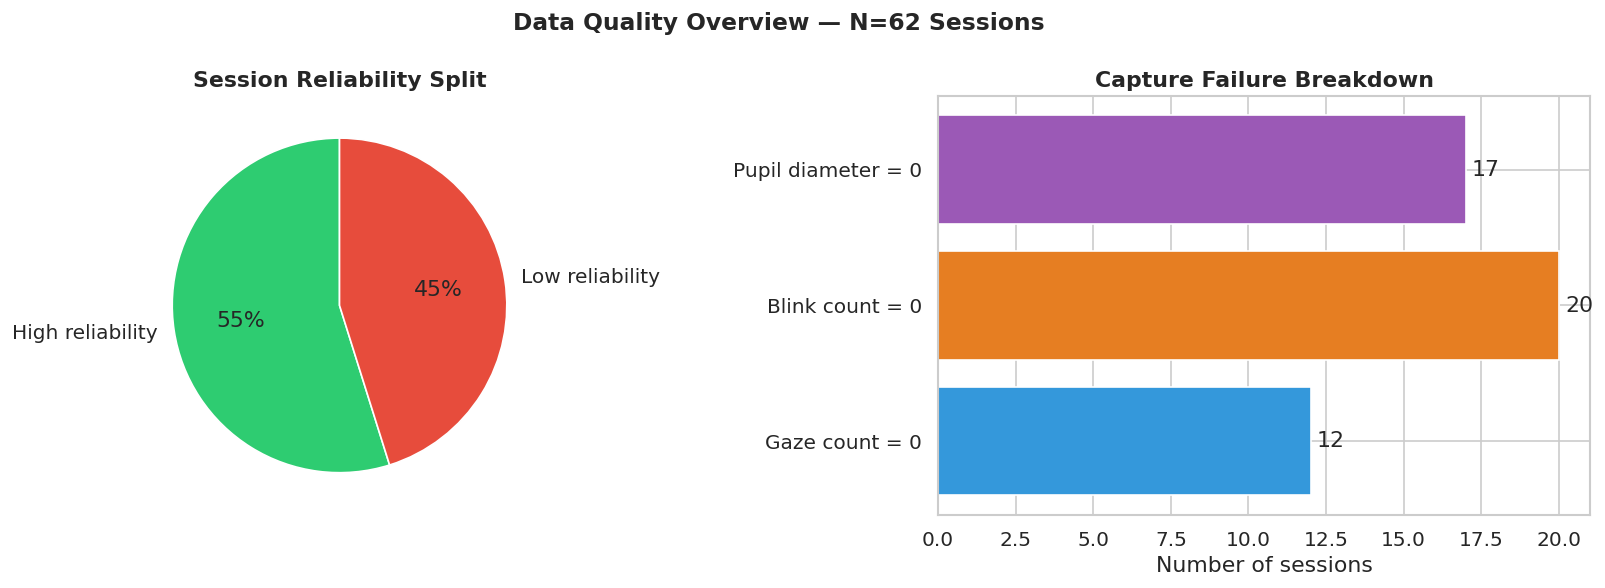

In [4]:
# ── Visualise failure modes ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
rel_counts = df['high_reliability'].value_counts()
axes[0].pie([rel_counts.get(True,0), rel_counts.get(False,0)],
            labels=['High reliability', 'Low reliability'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.0f%%', startangle=90)
axes[0].set_title('Session Reliability Split', fontweight='bold')

# Failure mode bar
failure_counts = {
    'Gaze count = 0': df['gaze_failed'].sum(),
    'Blink count = 0': df['blink_failed'].sum(),
    'Pupil diameter = 0': df['pupil_failed'].sum(),
}
axes[1].barh(list(failure_counts.keys()), list(failure_counts.values()),
             color=['#3498db','#e67e22','#9b59b6'])
axes[1].set_xlabel('Number of sessions')
axes[1].set_title('Capture Failure Breakdown', fontweight='bold')
for i, v in enumerate(failure_counts.values()):
    axes[1].text(v + 0.2, i, str(v), va='center')

plt.suptitle('Data Quality Overview — N=62 Sessions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Descriptive Statistics

We report descriptives for both the **full dataset** (n=62) and the **high-reliability subset** (n=34).


In [5]:
hr = df[df['high_reliability']].copy()

score_cols = ['globalScore','visualProcessing','responseSpeed','attentionStability','patternRecognition']
raw_feature_cols = ['pupilDiameter','blinkRate','fixationDuration','fixationStability',
                    'saccadeVelocity','gazeEntropy','calibrationQuality']

print("=== COGNITIVE SCORES — Full dataset (n=62) ===")
desc = df[score_cols].describe().T
desc['median'] = df[score_cols].median()
desc['skew']   = df[score_cols].skew()
print(desc[['count','mean','std','median','min','max','skew']].round(2).to_string())

print("\n=== COGNITIVE SCORES — High-reliability (n=34) ===")
desc_hr = hr[score_cols].describe().T
desc_hr['median'] = hr[score_cols].median()
desc_hr['skew']   = hr[score_cols].skew()
print(desc_hr[['count','mean','std','median','min','max','skew']].round(2).to_string())

print("\n=== RAW FEATURES — High-reliability only ===")
print(hr[raw_feature_cols].describe().round(3).to_string())


=== COGNITIVE SCORES — Full dataset (n=62) ===
                    count   mean    std  median   min   max  skew
globalScore          62.0  37.73  13.78    42.0  10.0  64.0 -0.23
visualProcessing     62.0  21.48  19.86    21.5   0.0  76.0  0.56
responseSpeed        62.0  21.85  19.65    20.0   0.0  79.0  0.49
attentionStability   62.0  19.92  24.96     0.0   0.0  70.0  0.64
patternRecognition   62.0  34.60  22.12    36.0   0.0  79.0 -0.21

=== COGNITIVE SCORES — High-reliability (n=34) ===
                    count   mean    std  median   min   max  skew
globalScore          34.0  43.21  10.78    43.5  14.0  64.0 -1.03
visualProcessing     34.0  31.00  18.25    33.0   0.0  76.0 -0.05
responseSpeed        34.0  33.47  17.87    34.5   0.0  79.0 -0.13
attentionStability   34.0  34.47  23.50    38.5   0.0  70.0 -0.44
patternRecognition   34.0  46.62  16.49    46.5   0.0  79.0 -0.35

=== RAW FEATURES — High-reliability only ===
       pupilDiameter  blinkRate  fixationDuration  fixationStab

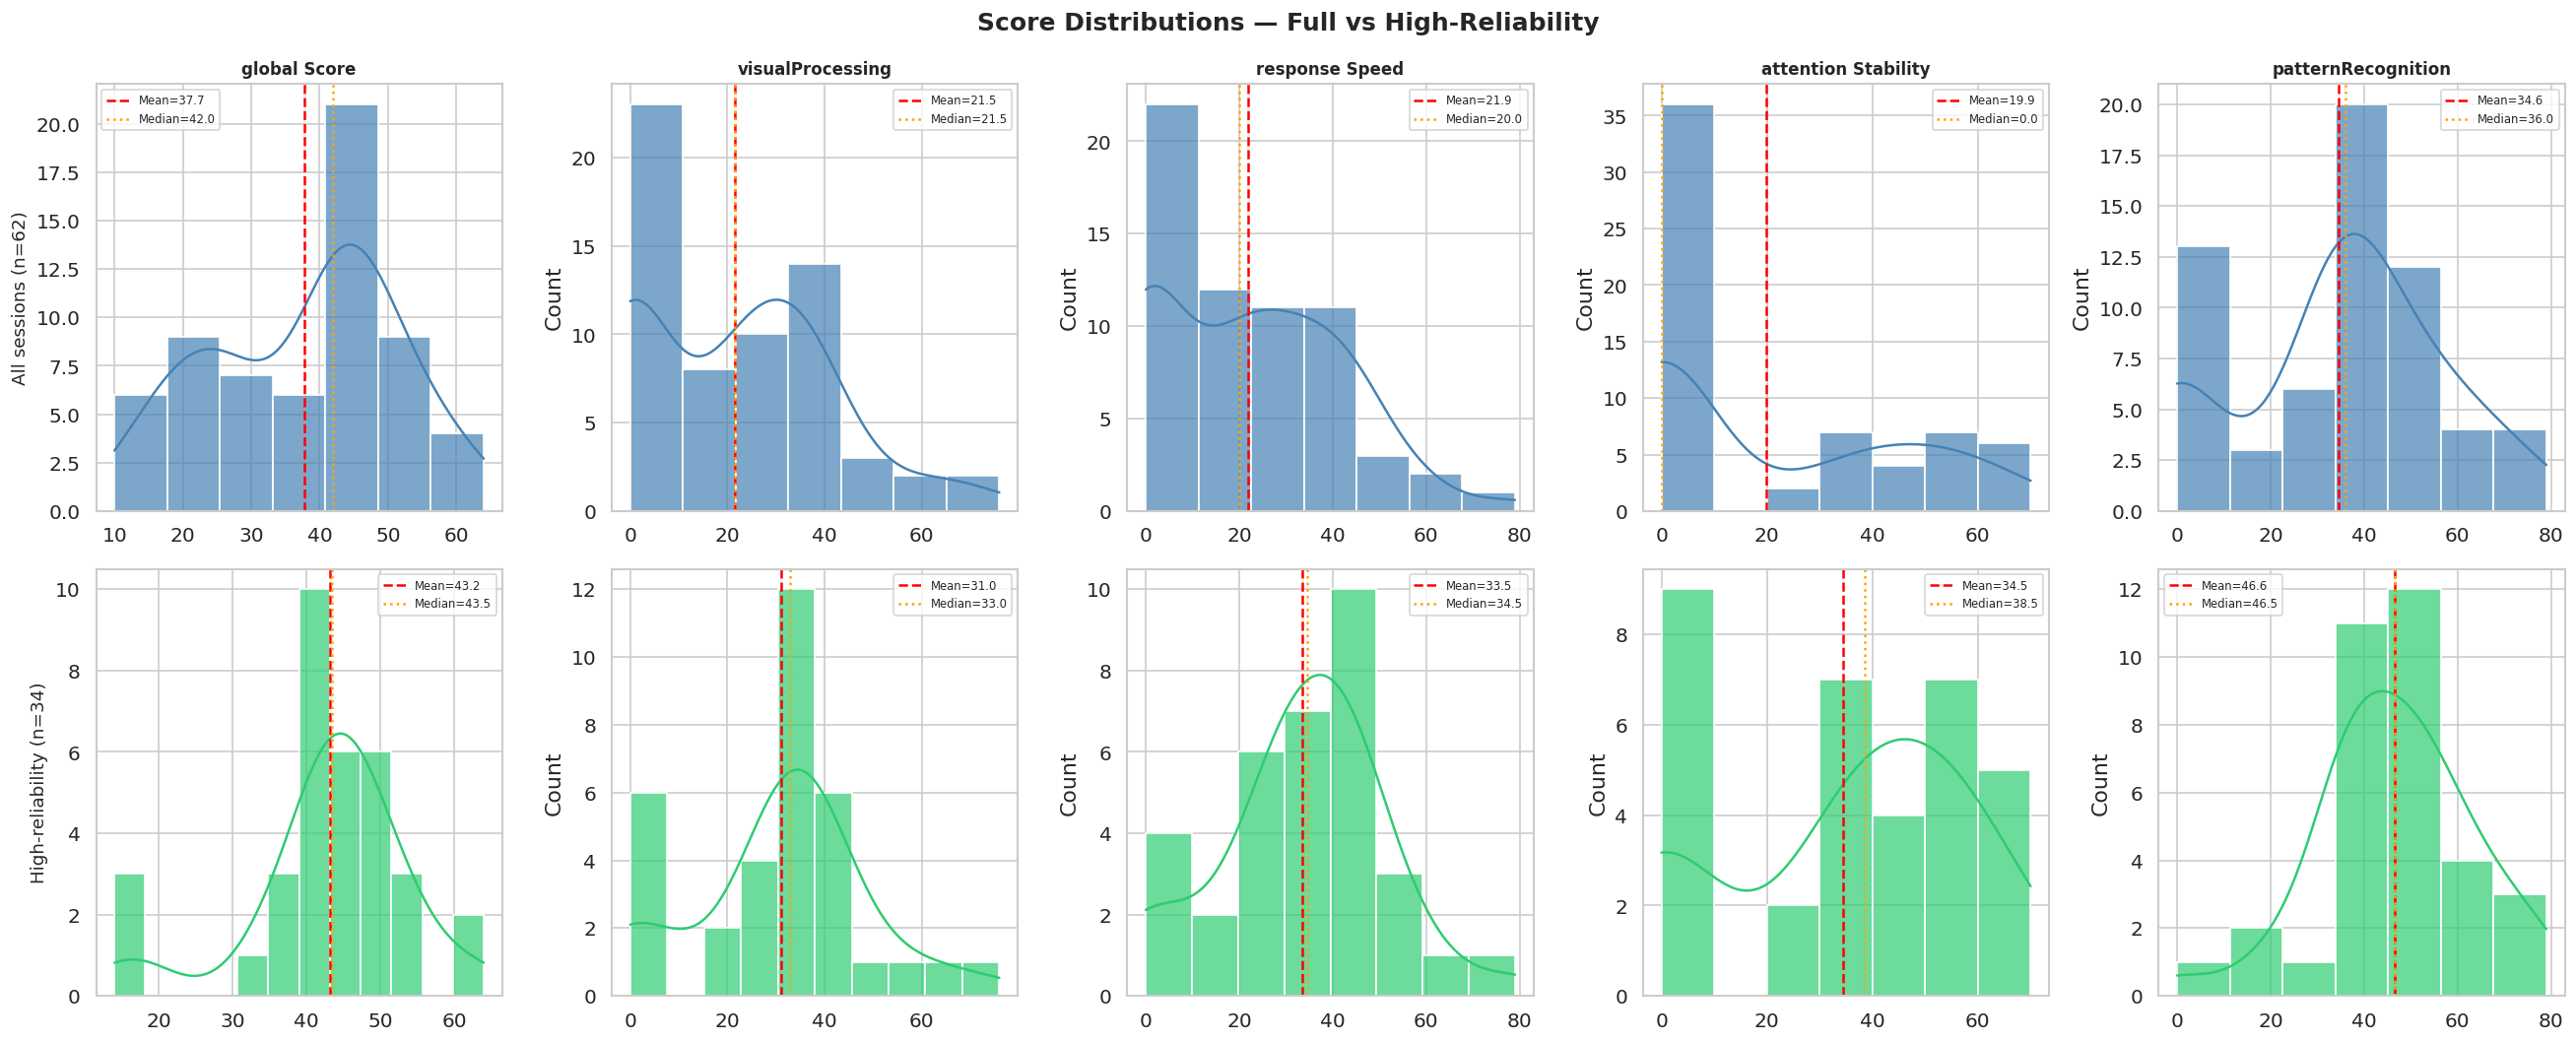

In [6]:
# ── Score distributions ──
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for i, col in enumerate(score_cols):
    # Full dataset
    sns.histplot(df[col], kde=True, ax=axes[0][i], color='steelblue',
                 edgecolor='white', alpha=0.7)
    axes[0][i].axvline(df[col].mean(), color='red', ls='--', lw=1.5,
                       label=f'Mean={df[col].mean():.1f}')
    axes[0][i].axvline(df[col].median(), color='orange', ls=':', lw=1.5,
                       label=f'Median={df[col].median():.1f}')
    axes[0][i].set_title(col.replace('S',' S').strip(), fontweight='bold', fontsize=10)
    axes[0][i].legend(fontsize=7)
    axes[0][i].set_xlabel('')

    # High-reliability
    sns.histplot(hr[col], kde=True, ax=axes[1][i], color='#2ecc71',
                 edgecolor='white', alpha=0.7)
    axes[1][i].axvline(hr[col].mean(), color='red', ls='--', lw=1.5,
                       label=f'Mean={hr[col].mean():.1f}')
    axes[1][i].axvline(hr[col].median(), color='orange', ls=':', lw=1.5,
                       label=f'Median={hr[col].median():.1f}')
    axes[1][i].legend(fontsize=7)
    axes[1][i].set_xlabel('')

axes[0][0].set_ylabel('All sessions (n=62)', fontsize=11)
axes[1][0].set_ylabel('High-reliability (n=34)', fontsize=11)
plt.suptitle('Score Distributions — Full vs High-Reliability', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Normality Tests (Shapiro-Wilk)

Shapiro-Wilk determines whether parametric (ANOVA, Pearson) or
non-parametric (Kruskal-Wallis, Spearman) tests should be used.

> At n=34, the test is sensitive but not oversensitive. Results should be
> combined with visual inspection (histogram, Q-Q plot).

**Decision rule applied throughout this notebook:** because all cognitive scores
and most raw features are non-normal, **Kruskal-Wallis, Mann-Whitney, and Spearman**
are used as primary tests everywhere.


In [7]:
print("=== SHAPIRO-WILK NORMALITY TESTS (high-reliability, n=34) ===")
print(f"{'Variable':<25} {'W':>8} {'p':>10} {'Normal?':>8}")
print("-" * 55)
all_vars = score_cols + raw_feature_cols
for col in all_vars:
    data = hr[col].dropna()
    if len(data) >= 4:
        w, p = shapiro(data)
        normal = 'Yes' if p > 0.05 else 'No'
        print(f"{col:<25} {w:>8.4f} {p:>10.5f} {normal:>8}")


=== SHAPIRO-WILK NORMALITY TESTS (high-reliability, n=34) ===
Variable                         W          p  Normal?
-------------------------------------------------------
globalScore                 0.8873    0.00216       No
visualProcessing            0.9184    0.01461       No
responseSpeed               0.9526    0.14672      Yes
attentionStability          0.8763    0.00115       No
patternRecognition          0.9694    0.44489      Yes
pupilDiameter               0.2756    0.00000       No
blinkRate                   0.4390    0.00000       No
fixationDuration            0.6688    0.00000       No
fixationStability           0.8891    0.00239       No
saccadeVelocity             0.7874    0.00001       No
gazeEntropy                 0.7621    0.00001       No
calibrationQuality          0.9274    0.05953      Yes


## 5. Time-of-Day Patterns (Analysis B1)

**Question:** Does cognitive readiness differ across the four time windows
(Night, Morning, Afternoon, Evening)?

**Test:** Kruskal-Wallis (non-parametric one-way test), because distributions are non-normal.


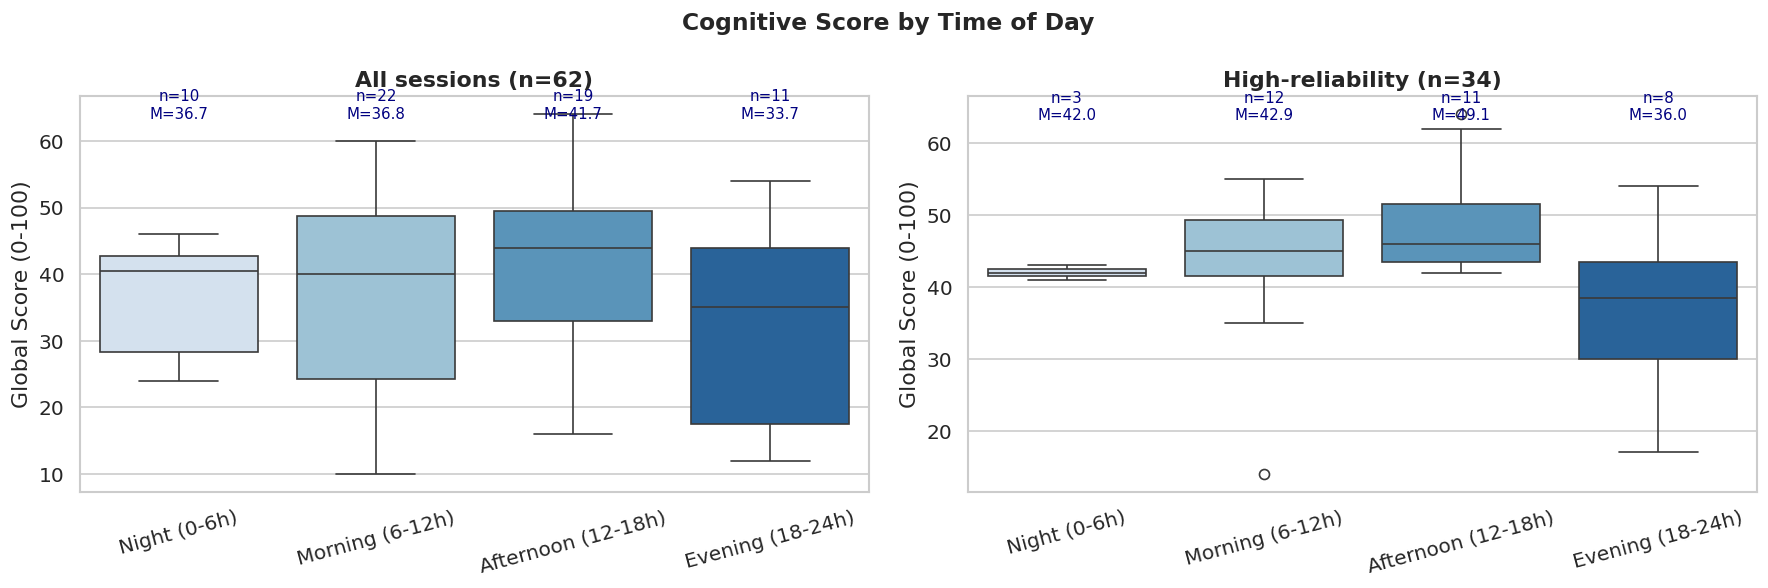


=== KRUSKAL-WALLIS: Global Score by Time Window ===
  [All sessions]  H=2.7856, p=0.42588 [ns]
                     mean  median  count
time_window                             
Night (0-6h)        36.70    40.5     10
Morning (6-12h)     36.77    40.0     22
Afternoon (12-18h)  41.68    44.0     19
Evening (18-24h)    33.73    35.0     11

  [High-reliability]  H=7.6809, p=0.05309 [ns]
                     mean  median  count
time_window                             
Night (0-6h)        42.00    42.0      3
Morning (6-12h)     42.92    45.0     12
Afternoon (12-18h)  49.09    46.0     11
Evening (18-24h)    36.00    38.5      8



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, data, title, color in zip(
        axes,
        [df, hr],
        ['All sessions (n=62)', 'High-reliability (n=34)'],
        ['steelblue', '#2ecc71']):

    means = data.groupby('time_window', observed=True)['globalScore'].mean()
    counts = data.groupby('time_window', observed=True)['globalScore'].count()

    bp = sns.boxplot(data=data, x='time_window', y='globalScore',
                     palette='Blues', ax=ax, order=[
                         'Night (0-6h)','Morning (6-12h)',
                         'Afternoon (12-18h)','Evening (18-24h)'])

    for i, (m, c) in enumerate(zip(means, counts)):
        ax.text(i, ax.get_ylim()[1]*0.95, f'n={c}\nM={m:.1f}',
                ha='center', fontsize=9, color='navy')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Global Score (0-100)')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Cognitive Score by Time of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical test
print("\n=== KRUSKAL-WALLIS: Global Score by Time Window ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    groups = [g['globalScore'].values for _, g in
              data.groupby('time_window', observed=True) if len(g) >= 3]
    h, p = kruskal(*groups)
    sig = '*' if p < 0.05 else 'ns'
    print(f"  [{label}]  H={h:.4f}, p={p:.5f} [{sig}]")
    tw_means = data.groupby('time_window', observed=True)['globalScore'].agg(['mean','median','count'])
    print(tw_means.round(2).to_string())
    print()


## 6. High vs Low Reliability Comparison (Analysis B2)

**Question:** Do high-reliability sessions produce systematically higher cognitive scores,
or does the reliability flag not matter?

**Why this matters:** If high-reliability sessions score significantly higher, the flag is
capturing a genuine cognitive signal. If not, the platform is robust to tracking noise.

**Test:** Mann-Whitney U + rank-biserial r effect size.


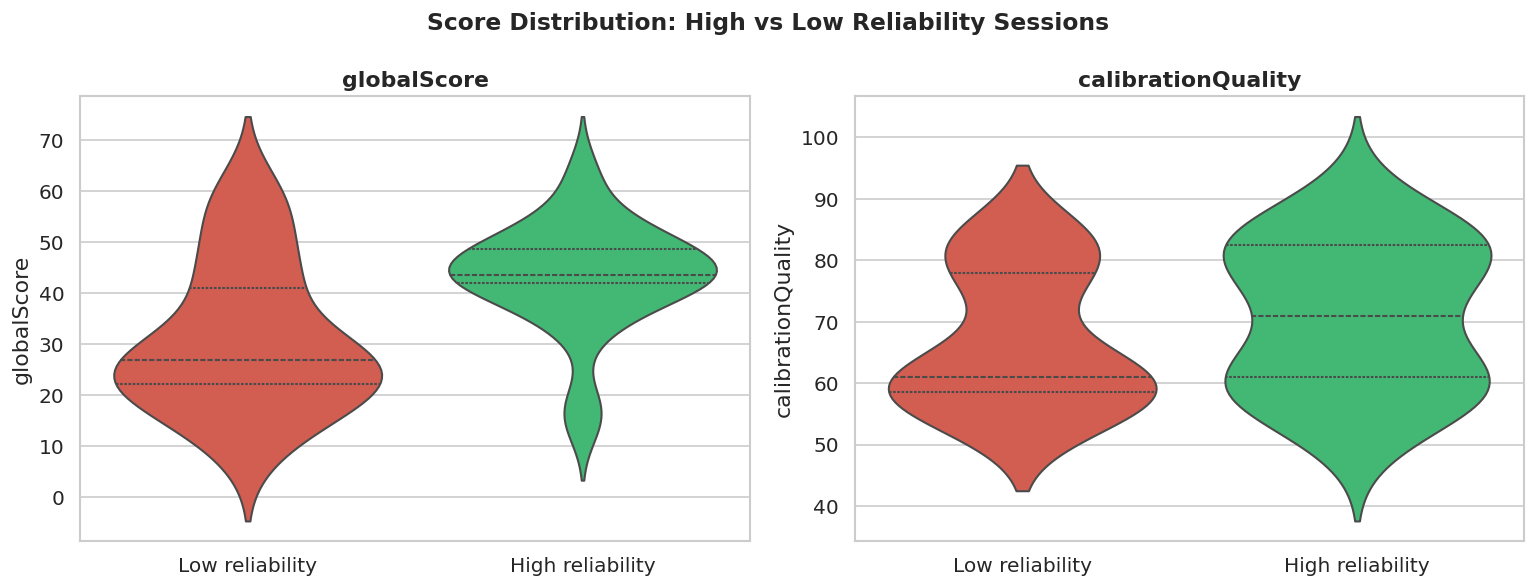

=== MANN-WHITNEY U: High vs Low Reliability ===
  U=704, p=0.00128, rank-biserial r=-0.479
  High-rel: median=43.5, mean=43.2, n=34
  Low-rel:  median=27.0, mean=31.1, n=28
  Interpretation: Significant — flag captures genuine signal


In [10]:
# --- 8a/B2. Reliability comparison violin plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fix: map boolean to string label for seaborn compatibility
df['reliability_label'] = df['high_reliability'].map(
    {True: 'High reliability', False: 'Low reliability'}
)

for ax, col in zip(axes, ['globalScore', 'calibrationQuality']):
    sns.violinplot(data=df, x='reliability_label', y=col,
                   order=['Low reliability', 'High reliability'],
                   palette={'High reliability': '#2ecc71', 'Low reliability': '#e74c3c'},
                   inner='quartile', ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Score Distribution: High vs Low Reliability Sessions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mann-Whitney test
hi = df[df['high_reliability']]['globalScore'].dropna()
lo = df[~df['high_reliability']]['globalScore'].dropna()
u, p = mannwhitneyu(hi, lo, alternative='two-sided')
r_rb = 1 - (2 * u) / (len(hi) * len(lo))

print("=== MANN-WHITNEY U: High vs Low Reliability ===")
print(f"  U={u:.0f}, p={p:.5f}, rank-biserial r={r_rb:.3f}")
print(f"  High-rel: median={hi.median():.1f}, mean={hi.mean():.1f}, n={len(hi)}")
print(f"  Low-rel:  median={lo.median():.1f}, mean={lo.mean():.1f}, n={len(lo)}")
print(f"  Interpretation: {'Significant — flag captures genuine signal' if p < 0.05 else 'Not significant'}")

## 7. Suhoor Timing Effect (Analyses A3 & A6)

**Question:** Does the timing of the pre-dawn meal (Suhoor) before Fajr
predict cognitive readiness scores?

**Hypothesis:** Earlier Suhoor → longer time since eating → possibly lower scores
(dose-response). But the No-Suhoor group may be confounded by more sleep.

**Test:** Kruskal-Wallis + Dunn post-hoc (Bonferroni corrected).

> No-Suhoor group (n=7): treated as exploratory. Effect sizes reported but
> no significance claimed.


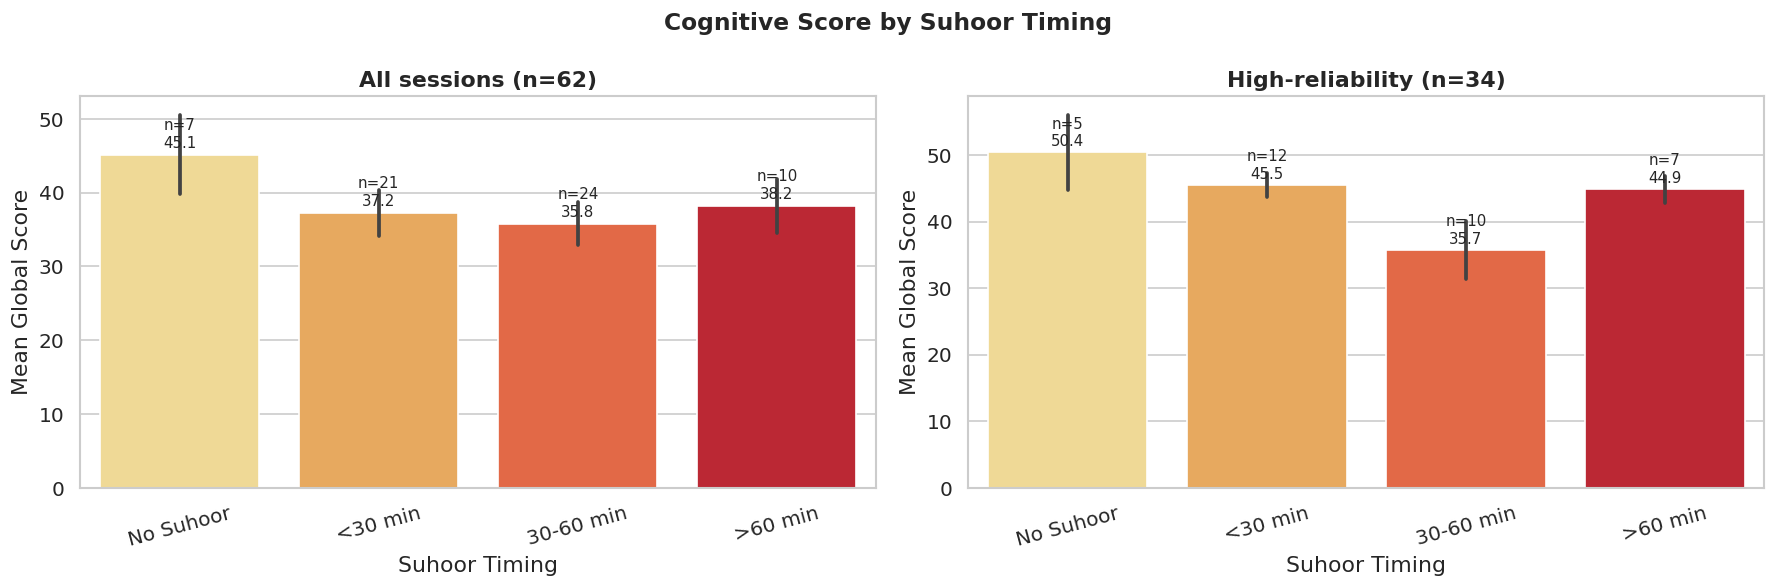

=== KRUSKAL-WALLIS: Global Score by Suhoor Timing ===
  [All sessions]  H=1.8256, p=0.60938 ns
                                   mean  median  count
suhoorTiming                                          
I did not have Suhoor today       45.14    44.0      7
Less than 30 minutes before Fajr  37.24    42.0     21
30-60 minutes before Fajr         35.79    41.5     24
More than 60 minutes before Fajr  38.20    43.5     10

  [High-reliability]  H=4.0211, p=0.25920 ns
                                   mean  median  count
suhoorTiming                                          
I did not have Suhoor today       50.40    48.0      5
Less than 30 minutes before Fajr  45.50    43.0     12
30-60 minutes before Fajr         35.70    43.0     10
More than 60 minutes before Fajr  44.86    45.0      7



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

suhoor_short = {
    'I did not have Suhoor today': 'No Suhoor',
    'Less than 30 minutes before Fajr': '<30 min',
    '30-60 minutes before Fajr': '30-60 min',
    'More than 60 minutes before Fajr': '>60 min'
}

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=62)', 'High-reliability (n=34)']):
    plot_data = data.copy()
    plot_data['suhoor_label'] = plot_data['suhoorTiming'].map(suhoor_short)
    order = ['No Suhoor', '<30 min', '30-60 min', '>60 min']

    means = plot_data.groupby('suhoor_label')['globalScore'].agg(['mean','count'])

    sns.barplot(data=plot_data, x='suhoor_label', y='globalScore',
                order=order, palette='YlOrRd', errorbar='se', ax=ax)

    for i, lbl in enumerate(order):
        if lbl in means.index:
            m = means.loc[lbl,'mean']
            n = means.loc[lbl,'count']
            ax.text(i, m + 1, f'n={n}\n{m:.1f}', ha='center', fontsize=9)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Suhoor Timing')
    ax.set_ylabel('Mean Global Score')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Cognitive Score by Suhoor Timing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical tests
print("=== KRUSKAL-WALLIS: Global Score by Suhoor Timing ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    groups = {k: v['globalScore'].dropna().values
              for k, v in data.groupby('suhoorTiming', observed=True)
              if len(v) >= 3}
    if len(groups) >= 2:
        h, p = kruskal(*groups.values())
        print(f"  [{label}]  H={h:.4f}, p={p:.5f} {'*' if p<0.05 else 'ns'}")
        means_t = data.groupby('suhoorTiming', observed=True)['globalScore'].agg(['mean','median','count'])
        print(means_t.round(2).to_string())
    print()


## 8. Sleep Stratification (Analysis B4)

**Question:** Does sleep duration the night before modulate cognitive readiness?

**Key finding to test:** Whether sleep × fasting interact — does sleep debt amplify
the fasting effect, or does it drive cognitive decline independently?

**Test:** Kruskal-Wallis across sleep strata.


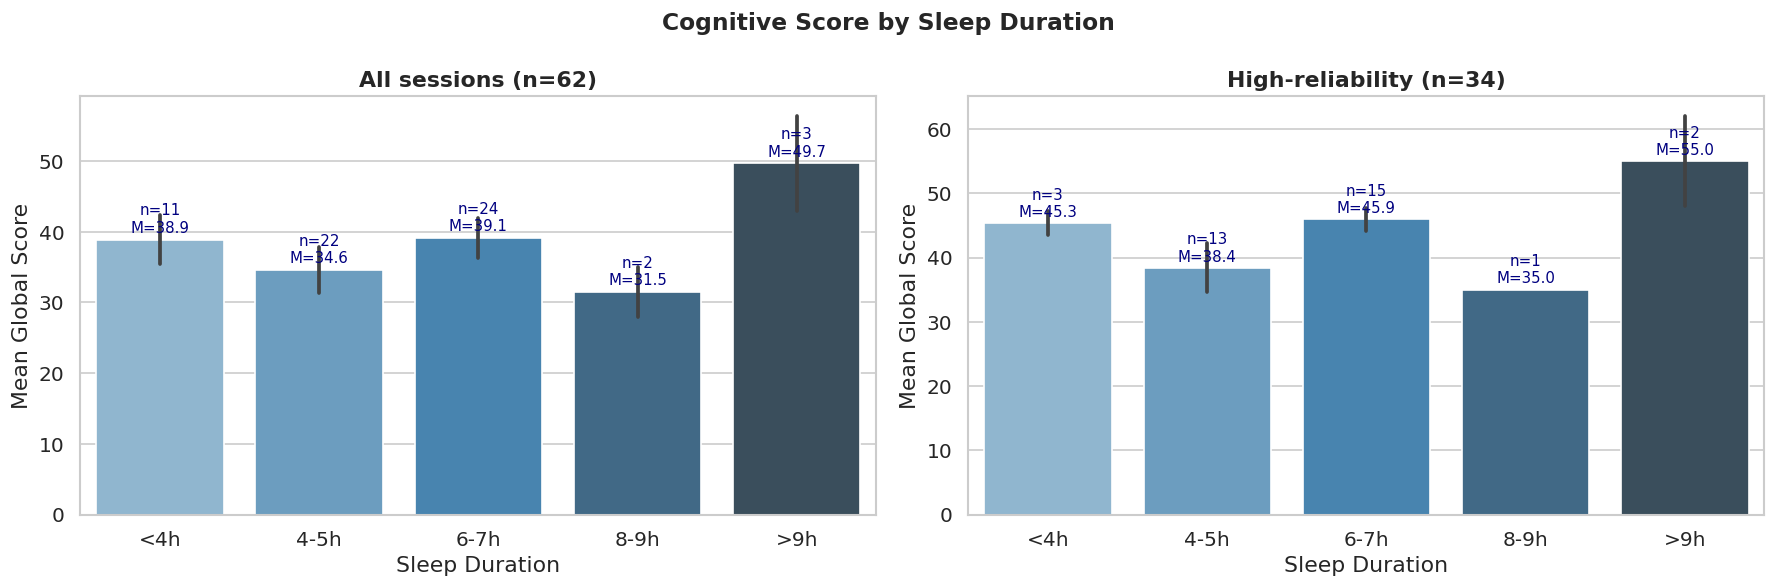

=== KRUSKAL-WALLIS: Global Score by Sleep Strata ===
  [All sessions]  H=3.3084, p=0.34647 ns
                    mean  median  count
sleepHours                             
Less than 4 hours  38.91    43.0     11
4-5 hours          34.59    38.0     22
6-7 hours          39.08    43.0     24
8-9 hours          31.50    31.5      2
More than 9 hours  49.67    48.0      3

  [High-reliability]  H=2.7842, p=0.24855 ns
                    mean  median  count
sleepHours                             
Less than 4 hours  45.33    44.0      3
4-5 hours          38.38    42.0     13
6-7 hours          45.93    45.0     15
8-9 hours          35.00    35.0      1
More than 9 hours  55.00    55.0      2



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sleep_short = {
    'Less than 4 hours': '<4h',
    '4-5 hours': '4-5h',
    '6-7 hours': '6-7h',
    '8-9 hours': '8-9h',
    'More than 9 hours': '>9h'
}
sleep_order_short = ['<4h','4-5h','6-7h','8-9h','>9h']

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=62)', 'High-reliability (n=34)']):
    plot_data = data.copy()
    plot_data['sleep_label'] = plot_data['sleepHours'].map(sleep_short)

    means = plot_data.groupby('sleep_label')['globalScore'].agg(['mean','count'])

    sns.barplot(data=plot_data, x='sleep_label', y='globalScore',
                order=sleep_order_short, palette='Blues_d', errorbar='se', ax=ax)

    for i, lbl in enumerate(sleep_order_short):
        if lbl in means.index:
            m = means.loc[lbl,'mean']
            n = means.loc[lbl,'count']
            ax.text(i, m + 1, f'n={n}\nM={m:.1f}', ha='center', fontsize=9, color='navy')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sleep Duration')
    ax.set_ylabel('Mean Global Score')

plt.suptitle('Cognitive Score by Sleep Duration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== KRUSKAL-WALLIS: Global Score by Sleep Strata ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    groups = [g['globalScore'].dropna().values
              for _, g in data.groupby('sleepHours', observed=True) if len(g) >= 3]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f"  [{label}]  H={h:.4f}, p={p:.5f} {'*' if p<0.05 else 'ns'}")
        means_s = data.groupby('sleepHours', observed=True)['globalScore'].agg(['mean','median','count'])
        print(means_s.round(2).to_string())
    print()


## 9. Gender Analysis (Analysis E1)

**Question:** Does gender predict cognitive readiness, and do session trajectories
differ by gender across time of day?

**Note:** With 7F / 9M (and 3 N/A) at the participant level, trajectory analysis
is exploratory. Female and Male groups are adequately sized for the omnibus test.

**Tests:** Kruskal-Wallis + Mann-Whitney pairwise (Bonferroni corrected).


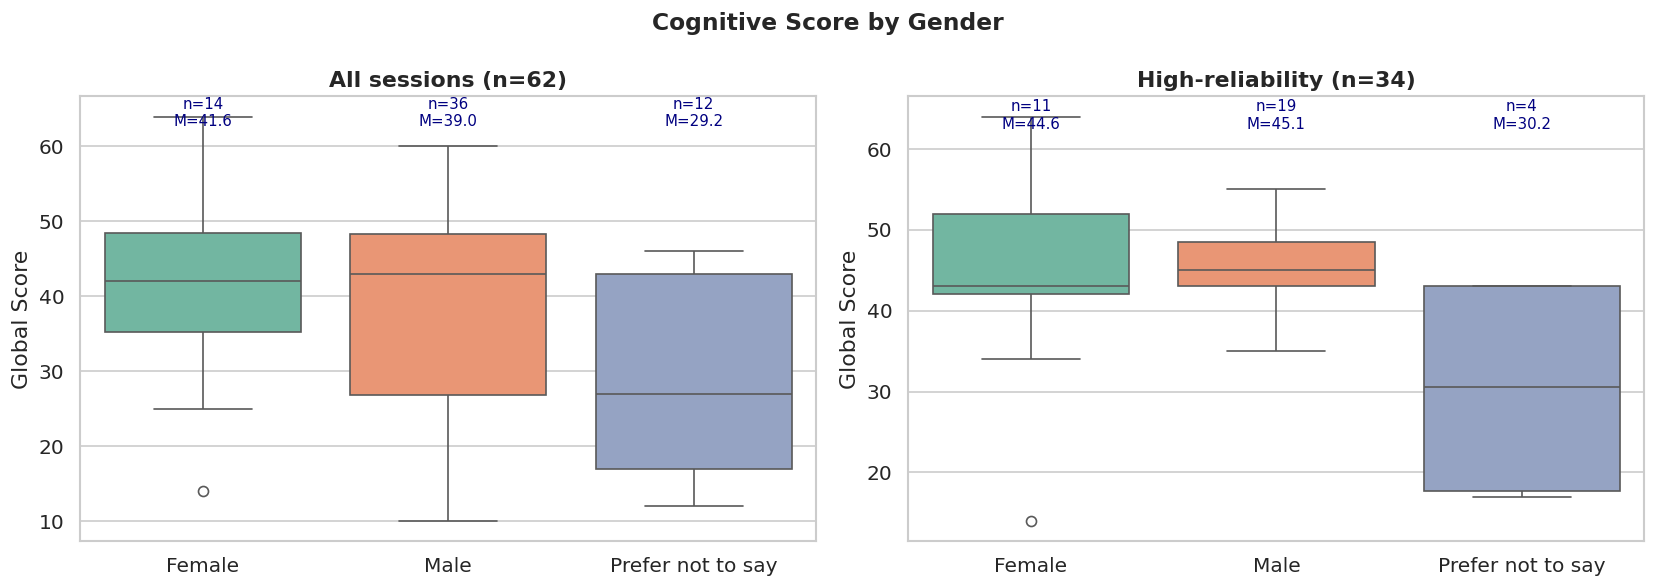

=== KRUSKAL-WALLIS: Global Score by Gender ===
  [All sessions]  H=5.3219, p=0.06988 ns

  [High-reliability]  H=0.1344, p=0.71390 ns

=== PAIRWISE MANN-WHITNEY (Bonferroni corrected, all sessions) ===
  Number of comparisons: 3 → Bonferroni α = 0.0167
  Female vs Male: U=264, p_raw=0.8036, p_bonf=1.0000 [ns]
  Female vs Prefer not to say: U=118, p_raw=0.0843, p_bonf=0.2530 [ns]
  Male vs Prefer not to say: U=311, p_raw=0.0243, p_bonf=0.0728 [ns]


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=62)', 'High-reliability (n=34)']):
    gender_order = ['Female', 'Male', 'Prefer not to say']
    valid = data[data['student.questionnaireGender'].isin(gender_order)]

    sns.boxplot(data=valid, x='student.questionnaireGender', y='globalScore',
                order=gender_order, palette='Set2', ax=ax)

    means_g = valid.groupby('student.questionnaireGender')['globalScore'].agg(['mean','count'])
    for i, g in enumerate(gender_order):
        if g in means_g.index:
            m = means_g.loc[g,'mean']
            n = means_g.loc[g,'count']
            ax.text(i, ax.get_ylim()[1]*0.94, f'n={n}\nM={m:.1f}', ha='center', fontsize=9, color='navy')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Global Score')

plt.suptitle('Cognitive Score by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== KRUSKAL-WALLIS: Global Score by Gender ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    groups_dict = {k: v['globalScore'].dropna().values
                   for k, v in data.groupby('student.questionnaireGender') if len(v) >= 5}
    if len(groups_dict) >= 2:
        h, p = kruskal(*groups_dict.values())
        print(f"  [{label}]  H={h:.4f}, p={p:.5f} {'*' if p<0.05 else 'ns'}")
    print()

print("=== PAIRWISE MANN-WHITNEY (Bonferroni corrected, all sessions) ===")
groups_dict = {k: v['globalScore'].dropna().values
               for k, v in df.groupby('student.questionnaireGender') if len(v) >= 5}
n_comp = len(list(combinations(groups_dict.keys(), 2)))
print(f"  Number of comparisons: {n_comp} → Bonferroni α = {0.05/n_comp:.4f}")
for (g1,v1),(g2,v2) in combinations(groups_dict.items(), 2):
    u, p_raw = mannwhitneyu(v1, v2, alternative='two-sided')
    p_bonf = min(p_raw * n_comp, 1.0)
    sig = '***' if p_bonf<0.001 else '**' if p_bonf<0.01 else '*' if p_bonf<0.05 else 'ns'
    print(f"  {g1} vs {g2}: U={u:.0f}, p_raw={p_raw:.4f}, p_bonf={p_bonf:.4f} [{sig}]")


## 10. Device Type Effect (Analysis B3)

**Question:** Does the type of device (Laptop, Desktop, Tablet) affect
cognitive scores or calibration quality?

**Expected finding:** Tablets should show worse calibration accuracy, but the
global score difference may not be significant.


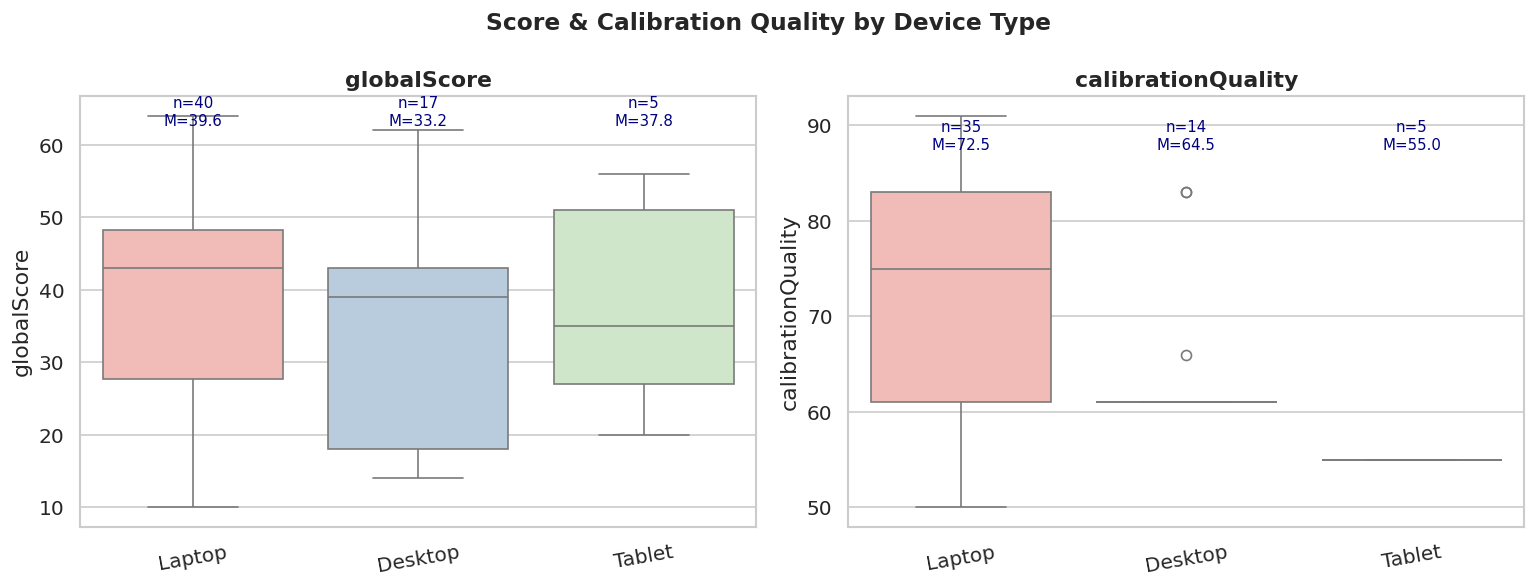

=== KRUSKAL-WALLIS: Device Type ===
  globalScore: H=3.1337, p=0.20870 ns
  calibrationQuality: H=12.7514, p=0.00170 *


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_col in zip(axes, ['globalScore', 'calibrationQuality']):
    dev_order = ['Laptop', 'Desktop computer', 'Tablet (iPad, Android tablet, etc.)']
    sns.boxplot(data=df, x='student.deviceUsed', y=y_col,
                order=dev_order, palette='Pastel1', ax=ax)

    means_d = df.groupby('student.deviceUsed')[y_col].agg(['mean','count'])
    for i, d in enumerate(dev_order):
        if d in means_d.index:
            m = means_d.loc[d,'mean']
            n = means_d.loc[d,'count']
            ax.text(i, ax.get_ylim()[1]*0.94, f'n={n}\nM={m:.1f}', ha='center', fontsize=9, color='navy')

    ax.set_xticklabels(['Laptop', 'Desktop', 'Tablet'], rotation=10)
    ax.set_title(y_col, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Score & Calibration Quality by Device Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== KRUSKAL-WALLIS: Device Type ===")
for y_col in ['globalScore', 'calibrationQuality']:
    groups = [g[y_col].dropna().values for _, g in df.groupby('student.deviceUsed') if len(g) >= 3]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f"  {y_col}: H={h:.4f}, p={p:.5f} {'*' if p<0.05 else 'ns'}")


## 11. Calibration as an Analytical Variable (Analysis F3)

**Question:** Does calibration quality (the score shown to participants before the
task) predict global cognitive score?

**Hypothesis (F3):** If calibration quality correlates with cognitive score,
the 2-minute calibration procedure itself is a valid cognitive readiness indicator.

**Test:** Spearman correlation (primary) + scatter plot.


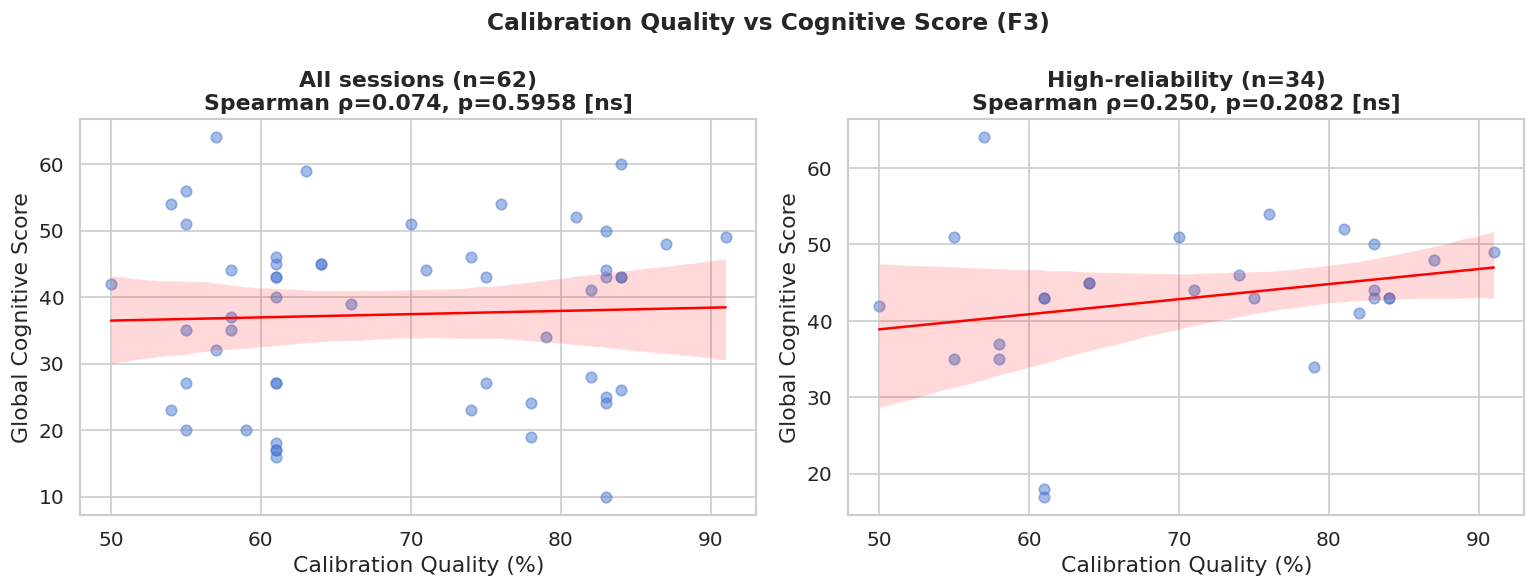

=== SPEARMAN CORRELATION: Calibration Quality vs Global Score ===
  [All sessions]  ρ=0.0738, p=0.59576, n=54
  [High-reliability]  ρ=0.2502, p=0.20815, n=27


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=62)', 'High-reliability (n=34)']):
    valid = data[['calibrationQuality','globalScore']].dropna()

    sns.regplot(data=valid, x='calibrationQuality', y='globalScore',
                scatter_kws={'alpha': 0.5, 's': 40},
                line_kws={'color': 'red', 'linewidth': 1.5}, ax=ax)

    rho, p = spearmanr(valid['calibrationQuality'], valid['globalScore'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.set_title(f'{title}\nSpearman ρ={rho:.3f}, p={p:.4f} [{sig}]', fontweight='bold')
    ax.set_xlabel('Calibration Quality (%)')
    ax.set_ylabel('Global Cognitive Score')

plt.suptitle('Calibration Quality vs Cognitive Score (F3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== SPEARMAN CORRELATION: Calibration Quality vs Global Score ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    valid = data[['calibrationQuality','globalScore']].dropna()
    rho, p = spearmanr(valid['calibrationQuality'], valid['globalScore'])
    print(f"  [{label}]  ρ={rho:.4f}, p={p:.5f}, n={len(valid)}")


## 12. Sub-Score Divergence — Metabolic Conservation Hypothesis (A5)

**Question:** Is Pattern Recognition significantly higher than Visual Processing
across sessions — and does this divergence represent a fasting-specific
cognitive conservation pattern?

**Hypothesis:** Fasting preserves higher-order attentional direction (prefrontal,
low metabolic cost) but degrades early visual processing (visual cortex, higher cost).

**Test:** One-sample Wilcoxon signed-rank on divergence = Pattern Recognition − Visual Processing.


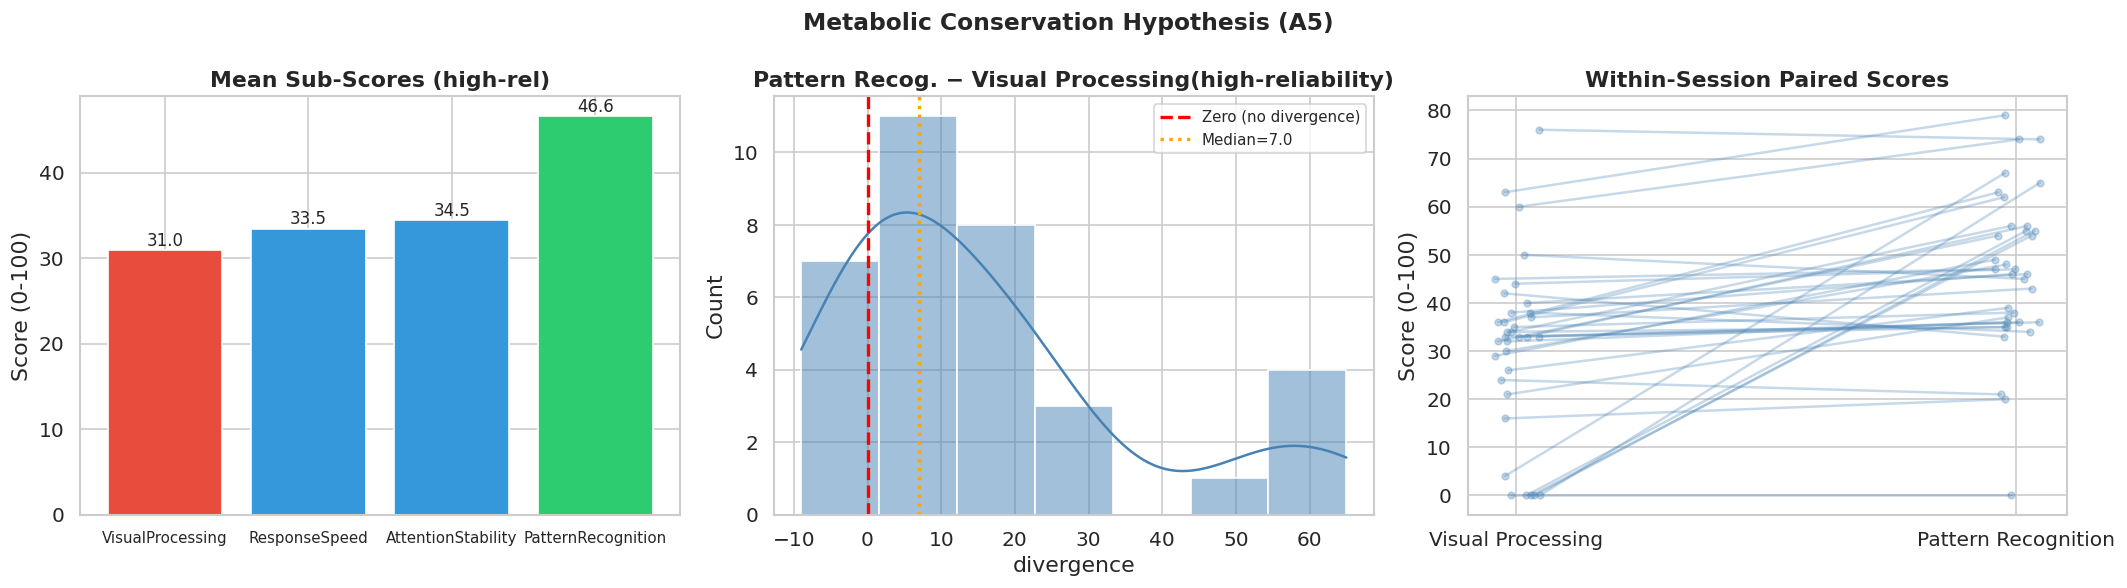

=== WILCOXON SIGNED-RANK: Divergence (Pattern Recog. - Visual Processing) ===
  [All sessions]  W=74, p=0.00000 [***]
    Mean=13.11, Median=6.50

  [High-reliability]  W=51, p=0.00004 [***]
    Mean=15.62, Median=7.00



In [22]:
hr['divergence'] = hr['patternRecognition'] - hr['visualProcessing']
df['divergence']  = df['patternRecognition']  - df['visualProcessing']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart of mean sub-scores
sub_means = hr[['visualProcessing','responseSpeed','attentionStability','patternRecognition']].mean()
colors = ['#e74c3c','#3498db','#3498db','#2ecc71']
axes[0].bar(range(4), sub_means.values, color=colors, edgecolor='white')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['VisualProcessing','ResponseSpeed','AttentionStability','PatternRecognition'], fontsize=9)
for i, v in enumerate(sub_means.values):
    axes[0].text(i, v+0.5, f'{v:.1f}', ha='center', fontsize=10)
axes[0].set_title('Mean Sub-Scores (high-rel)', fontweight='bold')
axes[0].set_ylabel('Score (0-100)')

# Divergence distribution
sns.histplot(hr['divergence'], kde=True, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--', lw=2, label='Zero (no divergence)')
axes[1].axvline(hr['divergence'].median(), color='orange', ls=':', lw=2,
                label=f'Median={hr["divergence"].median():.1f}')
axes[1].set_title('Pattern Recog. − Visual Processing(high-reliability)', fontweight='bold')
axes[1].legend(fontsize=9)

# Paired dot per session
jitter = np.random.uniform(-0.05, 0.05, len(hr))
for _, row in hr.iterrows():
    axes[2].plot([0 + jitter[_% len(jitter)], 1 + jitter[_% len(jitter)]],
                 [row['visualProcessing'], row['patternRecognition']],
                 'o-', color='steelblue', alpha=0.3, markersize=4)
axes[2].set_xticks([0,1])
axes[2].set_xticklabels(['Visual Processing', 'Pattern Recognition'])
axes[2].set_ylabel('Score (0-100)')
axes[2].set_title('Within-Session Paired Scores', fontweight='bold')

plt.suptitle('Metabolic Conservation Hypothesis (A5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== WILCOXON SIGNED-RANK: Divergence (Pattern Recog. - Visual Processing) ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    div = data['divergence'].dropna()
    w, p = wilcoxon(div)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  [{label}]  W={w:.0f}, p={p:.5f} [{sig}]")
    print(f"    Mean={div.mean():.2f}, Median={div.median():.2f}")
    print()


## 13. Raw Feature Correlations (High-Reliability Sessions)

**Question:** Which raw eye-tracking features correlate most strongly with
the global cognitive score?

This is the analysis the original notebook could not do — because it lacked
the raw feature values.


=== SPEARMAN CORRELATIONS WITH GLOBAL SCORE (high-reliability, n=34) ===
Variable                       rho          p    Sig
-----------------------------------------------------
pupilDiameter               0.2791    0.10999     ns
blinkRate                  -0.0315    0.85974     ns
fixationDuration           -0.5269    0.00137     **
fixationStability          -0.3775    0.02775      *
saccadeVelocity            -0.2562    0.14358     ns
gazeEntropy                 0.3549    0.03944      *
calibrationQuality          0.2502    0.20815     ns
visualProcessing            0.5739    0.00039    ***
responseSpeed               0.3954    0.02065      *
attentionStability          0.2207    0.20975     ns
patternRecognition          0.3445    0.04603      *


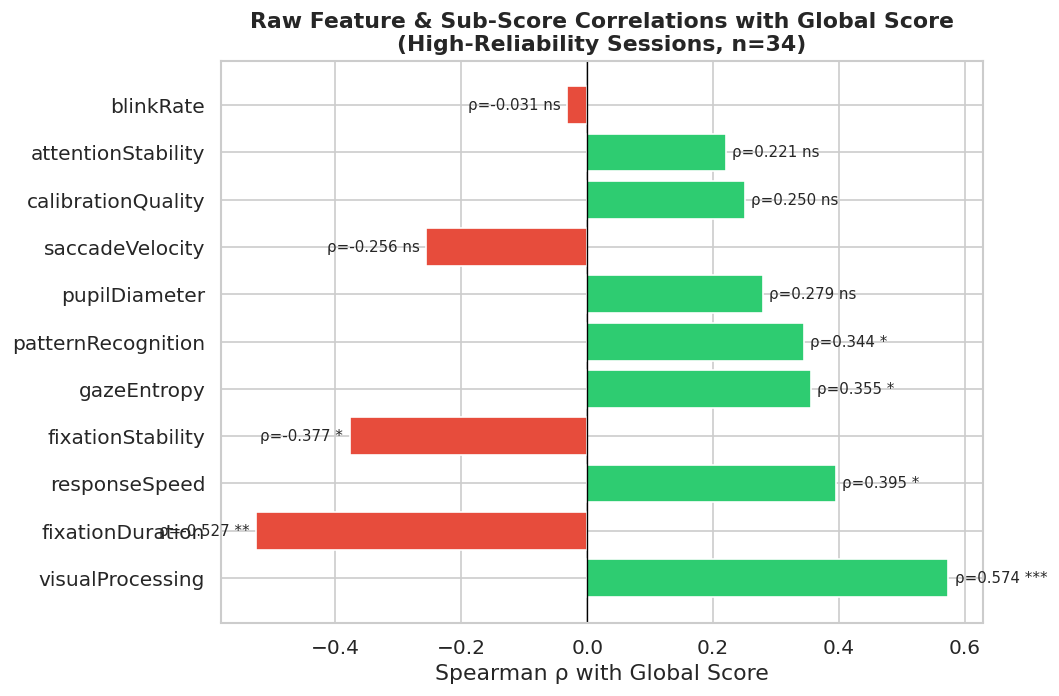

In [23]:
all_features = ['pupilDiameter','blinkRate','fixationDuration','fixationStability',
                'saccadeVelocity','gazeEntropy','calibrationQuality',
                'visualProcessing','responseSpeed','attentionStability','patternRecognition']

print("=== SPEARMAN CORRELATIONS WITH GLOBAL SCORE (high-reliability, n=34) ===")
print(f"{'Variable':<25} {'rho':>8} {'p':>10} {'Sig':>6}")
print("-"*53)
results = []
for col in all_features:
    data = hr[[col,'globalScore']].dropna()
    if len(data) >= 5:
        rho, p = spearmanr(data[col], data['globalScore'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f"{col:<25} {rho:>8.4f} {p:>10.5f} {sig:>6}")
        results.append({'variable': col, 'rho': rho, 'p': p, 'sig': sig})

results_df = pd.DataFrame(results).sort_values('rho', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in results_df['rho']]
ax.barh(results_df['variable'], results_df['rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Spearman ρ with Global Score")
ax.set_title("Raw Feature & Sub-Score Correlations with Global Score\n(High-Reliability Sessions, n=34)",
             fontweight='bold')
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(row['rho'] + (0.01 if row['rho'] >= 0 else -0.01), i,
            f"ρ={row['rho']:.3f} {row['sig']}",
            va='center', ha='left' if row['rho'] >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


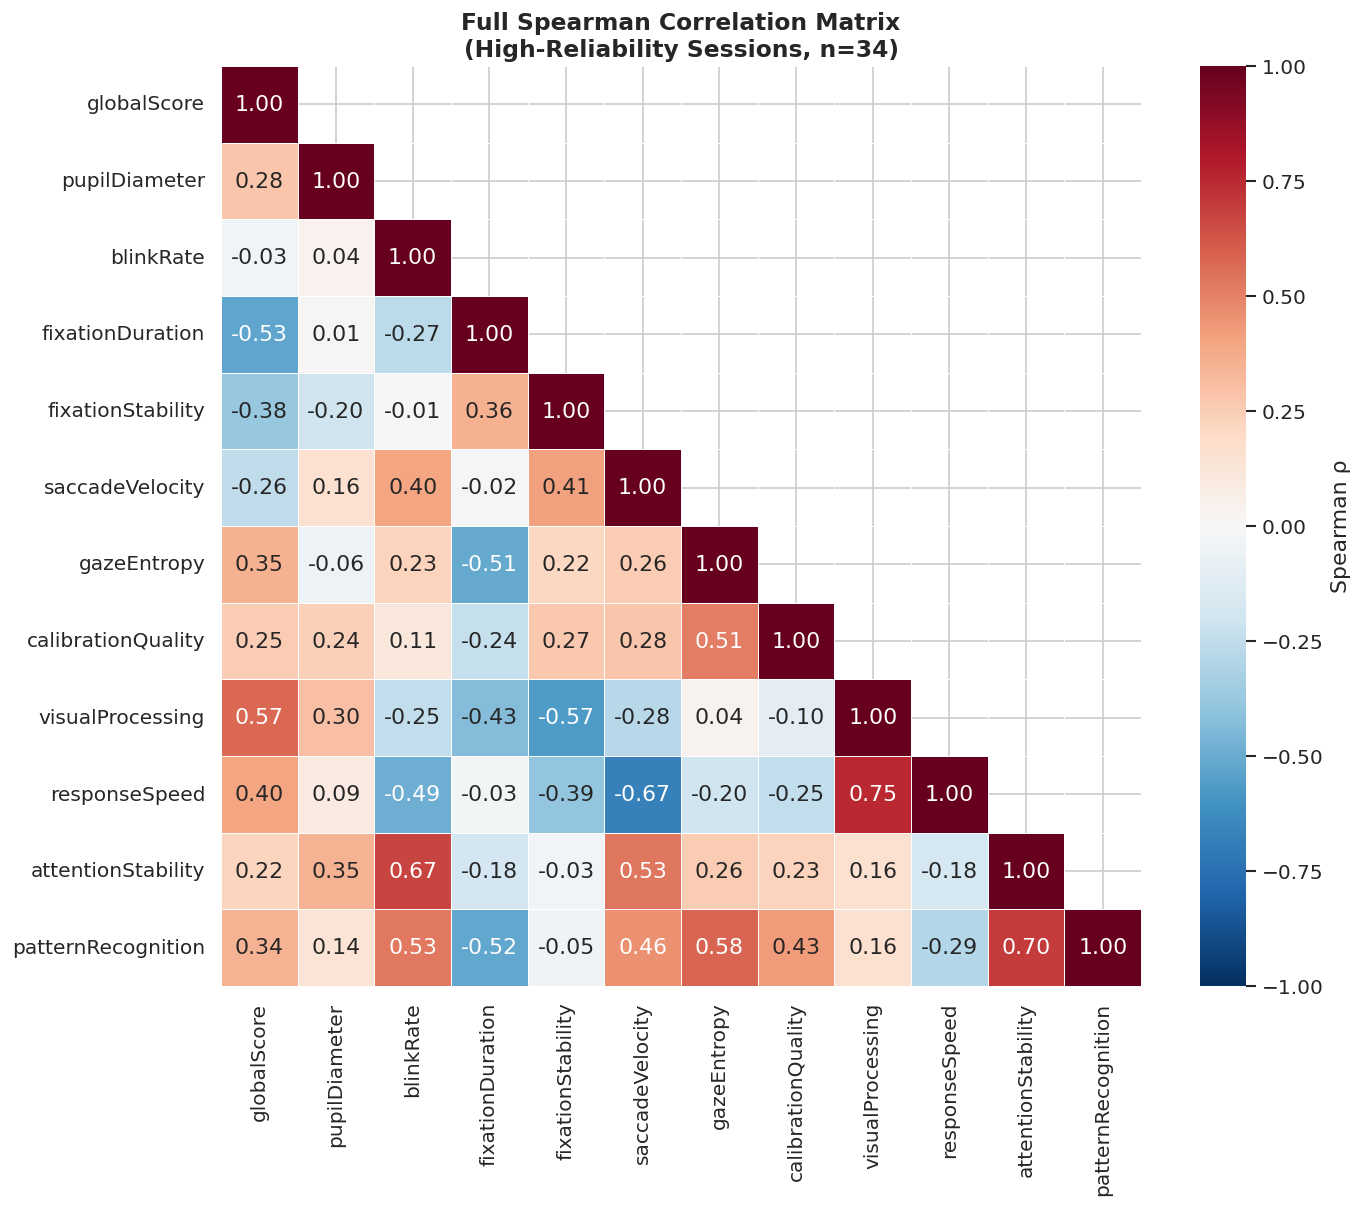

In [24]:
# Full correlation heatmap of all numeric variables
corr_cols = ['globalScore'] + all_features
corr_matrix = hr[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Spearman ρ'})
ax.set_title("Full Spearman Correlation Matrix\n(High-Reliability Sessions, n=34)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
*Generated by UM6P Human-AI Interaction Laboratory · Ramadan 2026*
